# Financial Feature Engineering

## Objective

The objective of this notebook is to generate financial metrics from historical market prices. These engineered features provide standardized measures of performance and risk, enabling meaningful comparisons across Bitcoin, Ethereum, Gold, and the S&P 500.

The resulting dataset will support statistical analysis, correlation analysis, and risk evaluation in subsequent notebooks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
PROCESSED_PATH = Path("crypto_project/data/processed")

market = pd.read_csv(
    PROCESSED_PATH / "market_data_master.csv"
)

market["Date"] = pd.to_datetime(market["Date"])

market.head()

,Date,Close,High,Low,Open,Volume,Asset
0,2019-01-01,3843.520020,3850.913818,3707.231201,3746.713379,4324200990,Bitcoin
1,2019-01-01,140.819412,141.397507,132.650711,133.418152,2258709868,Ethereum
2,2019-01-02,3943.409424,3947.981201,3817.409424,3849.216309,5244856836,Bitcoin
3,2019-01-02,155.047684,156.929138,140.650955,141.519516,3328240369,Ethereum
4,2019-01-02,121.330002,121.750000,120.879997,121.349998,12776200,Gold


## Daily Return

Daily Return is one of the most important features in financial analysis. It measures the percentage change in an asset's closing price from one trading day to the next.

### Formula

$$
\text{Daily Return} = \frac{P_t - P_{t-1}}{P_{t-1}}
$$ 

where:

 $$(P_t) =\text{ Closing price on the current day} $$
 $$(P_{t-1}) =\text{ Closing price on the previous day}$$

### Why is it important?

* Measures the day-to-day performance of an asset.
* Forms the basis for volatility and risk analysis.
* Enables meaningful comparison between assets with different price levels.
* Widely used in portfolio management, financial modeling, and machine learning.


In [3]:
market["Daily_Return"] = (
    market
    .groupby("Asset")["Close"]
    .pct_change()
)

### Interpretation

Positive Return (> 0): The asset gained value compared to the previous trading day.

Negative Return (< 0): The asset lost value compared to the previous trading day.

Zero Return (= 0): No change in the asset's closing price.

## Log Return

Log Return measures the continuously compounded return of an asset and is widely used in financial analysis because it is additive over time.

### Formula

$$
\text{Log Return} = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

where:

 $$(P_t) =\text{ Closing price on the current day} $$
 $$(P_{t-1}) =\text{ Closing price on the previous day}$$

### Why is it important?

- Additive over multiple time periods.
- Commonly used in quantitative finance and risk modeling.
- Suitable for statistical analysis and machine learning applications.

In [4]:
market["Log_Return"] = np.log(
    market["Close"] /
    market.groupby("Asset")["Close"].shift(1)
)

## Cumulative Return

Cumulative Return measures the total percentage gain or loss of an asset over a specified period by compounding the daily returns.

### Formula

$$
\text{Cumulative Return} =
\left[
\prod_{t=1}^{n}(1+r_t)
\right]-1
$$

where:

$$ r_t = \text{Daily return at time }t$$
$$ n = \text {Total number of trading periods}$$

### Why is it important?

- Measures the overall investment performance over time.
- Accounts for the compounding effect of returns.
- Enables comparison of long-term performance across different assets.

In [5]:
market["Cumulative_Return"] = (
    market
    .groupby("Asset")["Daily_Return"]
    .transform(
        lambda x:(1+x).cumprod()-1
    )
)

## Visualization

In [6]:
# Dark crypto theme
plt.style.use("dark_background")

crypto_palette = {
    "Bitcoin": "#F7931A",   # Orange
    "Ethereum": "#627EEA",  # Blue
    "Gold": "#FFD700",      # Gold
    "SP500": "#2ECC71"      # Green
}
sns.set_theme(
    style="darkgrid",
    context="talk",
)

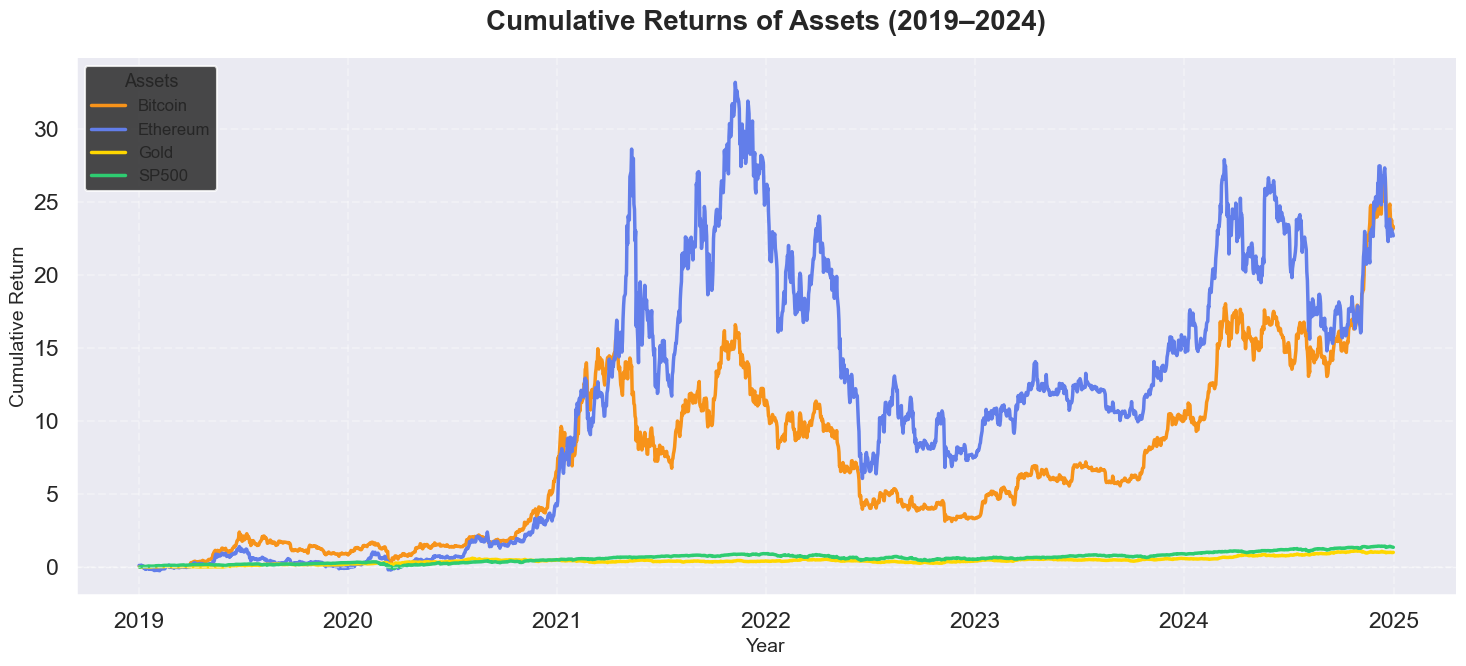

In [7]:
plt.figure(figsize=(15, 7))

# Plot cumulative returns for each asset
for asset in market["Asset"].unique():

    subset = market[market["Asset"] == asset]

    plt.plot(
        subset["Date"],
        subset["Cumulative_Return"],
        label=asset,
        color=crypto_palette[asset],
        linewidth=2.5
    )

# Reference line
plt.axhline(0, color="white", linestyle="--", linewidth=1, alpha=0.5)

plt.title(
    "Cumulative Returns of Assets (2019–2024)",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel("Year", fontsize=14)
plt.ylabel("Cumulative Return", fontsize=14)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.legend(
    title="Assets",
    fontsize=12,
    title_fontsize=13,
    frameon=True,
    facecolor="#1E1E1E",
    edgecolor="white"
)

sns.despine()

plt.tight_layout()
plt.show()

### Rolling Statistics

In [8]:
market["Rolling_Mean_30"] = (
    market
    .groupby("Asset")["Close"]
    .transform(
        lambda x:x.rolling(30).mean()
    )
)

In [9]:
market["Rolling_STD_30"] = (
    market
    .groupby("Asset")["Close"]
    .transform(
        lambda x:x.rolling(30).std()
    )
)

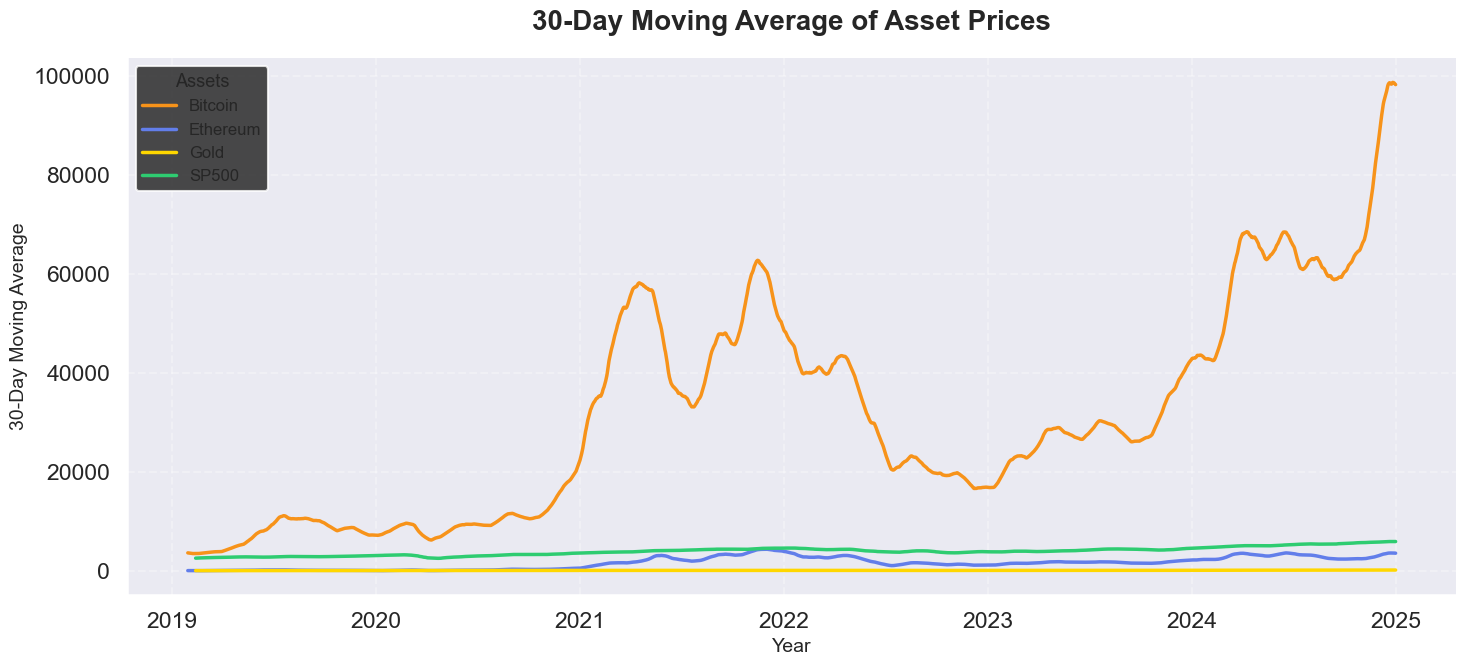

In [10]:
plt.figure(figsize=(15, 7))

# Plot 30-Day Moving Average for each asset
for asset in market["Asset"].unique():

    subset = market[market["Asset"] == asset]

    plt.plot(
        subset["Date"],
        subset["Rolling_Mean_30"],
        label=asset,
        color=crypto_palette[asset],
        linewidth=2.5
    )

plt.title(
    "30-Day Moving Average of Asset Prices",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel("Year", fontsize=14)
plt.ylabel("30-Day Moving Average", fontsize=14)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.legend(
    title="Assets",
    fontsize=12,
    title_fontsize=13,
    frameon=True,
    facecolor="#1E1E1E",
    edgecolor="white"
)

sns.despine()

plt.tight_layout()
plt.show()

### Interpretation

The 30-day moving average smooths short-term price fluctuations and highlights the underlying market trend.The moving average makes it easier to identify sustained bullish and bearish trends by reducing daily market noise.

## Feature Validation

In [11]:
market[
[
"Daily_Return",
"Log_Return",
"Cumulative_Return",
"Rolling_Mean_30",
"Rolling_STD_30"
]
].describe()

,Daily_Return,Log_Return,Cumulative_Return,Rolling_Mean_30,Rolling_STD_30
count,7400.000000,7400.000000,7400.000000,7288.000000,7288.000000
mean,0.001544,0.001067,5.584827,10625.899549,682.598940
std,0.030636,0.031029,7.260778,17780.055381,1376.691419
min,-0.423472,-0.550732,-0.257664,115.236225,0.676260
25%,-0.008648,-0.008685,0.441770,228.805402,16.319259
50%,0.000847,0.000846,1.120450,3174.423938,101.687584
75%,0.011006,0.010945,10.186883,9013.097489,521.870569
max,0.259475,0.230695,33.172046,98727.185156,11250.720172


In [12]:
market.isnull().sum()

Date                   0
Close                  0
High                   0
Low                    0
Open                   0
Volume                 0
Asset                  0
Daily_Return           4
Log_Return             4
Cumulative_Return      4
Rolling_Mean_30      116
Rolling_STD_30       116
dtype: int64

### Missing Values After Feature Engineering

The missing values are **expected** and result from the feature calculations:

* **Daily Return, Log Return & Cumulative Return:** The first record of each asset has no previous day's price, resulting in **4 missing values** (one per asset).
* **30-Day Rolling Mean & Rolling Standard Deviation:** These require **30 previous observations**, resulting in **29 missing values per asset** (**116 in total**).

These values are mathematical artifacts and will be removed before further analysis.


# Summary

Financial features were successfully generated for all assets.

The engineered dataset now includes:

- Daily Returns
- Log Returns
- Cumulative Returns
- 30-Day Rolling Mean
- 30-Day Rolling Standard Deviation

These metrics provide the basis for correlation analysis, volatility analysis, and hypothesis testing in the next stage.

### Output

market_features.csv

### Next Notebook

05_correlation_and_statistical_analysis.ipynb